## **This workflow includes data analysis and preprocessing techniques aimed at preparing the dataset for building a reliable predictive model for the target variable "PRICE"**

# Import Libraries

In [144]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df=pd.read_csv('/content/CarPrice_Assignment.csv')

# Data Overview

In [145]:
df.shape

(205, 26)

In [146]:
df.head().T  #transpose for better understanding

,0,1,2,3,4
car_ID,1,2,3,4,5
symboling,3,3,1,2,2
CarName,alfa-romero giulia,alfa-romero stelvio,alfa-romero Quadrifoglio,audi 100 ls,audi 100ls
fueltype,gas,gas,gas,gas,gas
aspiration,std,std,std,std,std
doornumber,two,two,two,four,four
carbody,convertible,convertible,hatchback,sedan,sedan
drivewheel,rwd,rwd,rwd,fwd,4wd
enginelocation,front,front,front,front,front
wheelbase,88.6,88.6,94.5,99.8,99.4


In [147]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel        205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize        205 non-null    int64  
 1

In [148]:
def information(data:pd.DataFrame):
  """
    This function returns a DataFrame containing the summary information for each column
    """

  Names=[col for col in data]
  data_types=[data[col].dtype for col in data.columns]
  top_10_unique_values=[data[col].value_counts().head(10).index.to_list() for col in data.columns]
  nunique_values=[data[col].nunique() for col in data.columns]
  nulls=[data[col].isnull().sum() for col in data.columns]
  percent_of_Nulls= [data[col].isnull().sum()/len(data)*100 for col in data.columns]
  duplicates=data.duplicated().sum()


  info_df=pd.DataFrame({'Name':Names,
                          'Data_Type':data_types,
                          'Top_10_Unique_Values':top_10_unique_values,
                          'Nunique_Values':nunique_values,
                          'Nulls':nulls,
                          'Percent_of_Nulls':percent_of_Nulls,
                          'Duplicates':duplicates})
  return info_df

information(df)

,Name,Data_Type,Top_10_Unique_Values,Nunique_Values,Nulls,Percent_of_Nulls,Duplicates
0,car_ID,int64,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",205,0,0.0,0
1,symboling,int64,"[0, 1, 2, 3, -1, -2]",6,0,0.0,0
2,CarName,object,"[peugeot 504, toyota corolla, toyota corona, s...",147,0,0.0,0
3,fueltype,object,"[gas, diesel]",2,0,0.0,0
4,aspiration,object,"[std, turbo]",2,0,0.0,0
5,doornumber,object,"[four, two]",2,0,0.0,0
6,carbody,object,"[sedan, hatchback, wagon, hardtop, convertible]",5,0,0.0,0
7,drivewheel,object,"[fwd, rwd, 4wd]",3,0,0.0,0
8,enginelocation,object,"[front, rear]",2,0,0.0,0
9,wheelbase,float64,"[94.5, 93.7, 95.7, 96.5, 98.4, 97.3, 96.3, 107...",53,0,0.0,0


#### Form this function the most important things I noticed about this data is:


1.   This data has no nulls and no duplicated rows
2.   'car_ID' column seems like an index, useless column must delete
3.   ['doornumber'  ,'aspiration'  ,'fueltype'  ,'enginelocation','drivewheel']
categorical columns, should convert them
4.   'cylindernumber' is obviously an int column. should convert it and its values.  



# Analysis and Visualizations to get Information about the data

In [149]:
df['cylindernumber'].unique()

array(['four', 'six', 'five', 'three', 'twelve', 'two', 'eight'],
      dtype=object)

In [150]:
#first convert data_types to their suitable types so i can work with them
mapping={
    'four':4,
    'six':6,
    'five':5,
    'three':3,
    'twelve':12,
    'two':2,
    'eight':8
}
df['cylindernumber']=df['cylindernumber'].map(mapping)
df['cylindernumber']=df['cylindernumber'].astype(int)

df['cylindernumber'].head()

,cylindernumber
0,4
1,4
2,6
3,4
4,5


In [151]:
# 2 mapping doornumber
mapping={
    'four':4,
    'two':2
}
df['doornumber']=df['doornumber'].map(mapping)
df['doornumber']=df['doornumber'].astype(int)

In [152]:
convert_to_category=['doornumber' ,'aspiration' ,'fueltype' ,'enginelocation','drivewheel']
df[convert_to_category]=df[convert_to_category].astype('category')

df[convert_to_category].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   doornumber      205 non-null    category
 1   aspiration      205 non-null    category
 2   fueltype        205 non-null    category
 3   enginelocation  205 non-null    category
 4   drivewheel      205 non-null    category
dtypes: category(5)
memory usage: 1.7 KB


In [153]:
#dropping 'car_ID' column
df.drop('car_ID',axis=1,inplace=True)

In [154]:
numerical_columns=df.select_dtypes(include='number').columns
numerical_columns

Index(['symboling', 'wheelbase', 'carlength', 'carwidth', 'carheight',
       'curbweight', 'cylindernumber', 'enginesize', 'boreratio', 'stroke',
       'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg',
       'price'],
      dtype='object')

In [155]:
categorical_columns=df.select_dtypes(include=['object','category']).columns
categorical_columns

Index(['CarName', 'fueltype', 'aspiration', 'doornumber', 'carbody',
       'drivewheel', 'enginelocation', 'enginetype', 'fuelsystem'],
      dtype='object')

 Analysis and Visualizations

Due to the high number of features, the strategy is to divide 'The analysis step' between numerical and categorical variables.

In [156]:
#1 Analysis
df[numerical_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
symboling,205.0,0.834146,1.245307,-2.00,0.00,1.00,2.00,3.00
wheelbase,205.0,98.756585,6.021776,86.60,94.50,97.00,102.40,120.90
carlength,205.0,174.049268,12.337289,141.10,166.30,173.20,183.10,208.10
carwidth,205.0,65.907805,2.145204,60.30,64.10,65.50,66.90,72.30
carheight,205.0,53.724878,2.443522,47.80,52.00,54.10,55.50,59.80
curbweight,205.0,2555.565854,520.680204,1488.00,2145.00,2414.00,2935.00,4066.00
cylindernumber,205.0,4.380488,1.080854,2.00,4.00,4.00,4.00,12.00
enginesize,205.0,126.907317,41.642693,61.00,97.00,120.00,141.00,326.00
boreratio,205.0,3.329756,0.270844,2.54,3.15,3.31,3.58,3.94
stroke,205.0,3.255415,0.313597,2.07,3.11,3.29,3.41,4.17


<Axes: xlabel='price', ylabel='Density'>

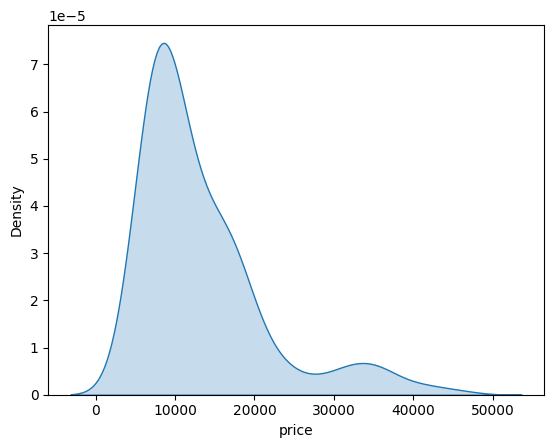

In [157]:
sns.kdeplot(data=df, x='price',fill=True) #the figure skewed to the right

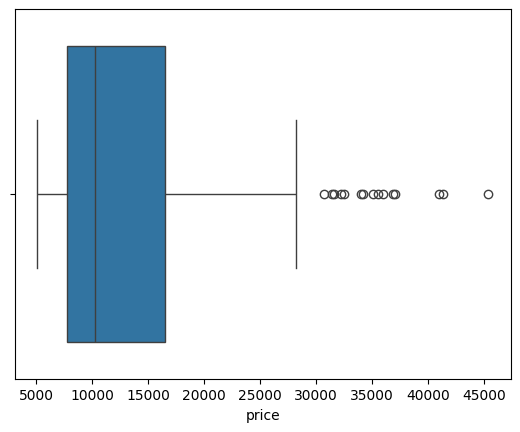

In [158]:
plt.figure()
sns.boxplot(x='price',data=df)
plt.show()
#it has outlier values greater than upper bound

In [159]:
df[['price']].describe().T

,count,mean,std,min,25%,50%,75%,max
price,205.0,13276.710571,7988.852332,5118.0,7788.0,10295.0,16503.0,45400.0


In [160]:
def count_outliers(df:pd.DataFrame,columns:list):
  q1=df[columns].quantile(0.25)
  q3=df[columns].quantile(0.75)
  IQR=q3-q1
  upperBound=q3+1.5*IQR
  lowerBound=q1-1.5*IQR

  mask=( (df[columns]>upperBound) |(df[columns]<lowerBound) )
  outlier_count=mask.sum().to_frame()
  percentage= outlier_count/len(df) *100
  return pd.DataFrame({
      'outlier_count':outlier_count.iloc[:,0],'percentage':percentage.iloc[:,0]
  }).sort_values(by='percentage',ascending=True)

count_outliers(df,numerical_columns).T

,symboling,carheight,curbweight,boreratio,carlength,peakrpm,citympg,wheelbase,highwaympg,horsepower,carwidth,enginesize,price,stroke,compressionratio,cylindernumber
outlier_count,0.0,0.0,0.0,0.0,1.000000,2.00000,2.00000,3.000000,3.000000,6.000000,8.000000,10.000000,15.000000,20.000000,28.000000,46.000000
percentage,0.0,0.0,0.0,0.0,0.487805,0.97561,0.97561,1.463415,1.463415,2.926829,3.902439,4.878049,7.317073,9.756098,13.658537,22.439024


##### Conclusion:
there is outliers at: cylindernumber, compressionratio, stroke, price, enginesize, carwidth, horsepower, highwaympg, wheelbase, citympg, peakrpm, carlength.

with total 11 column.

each of them has a different outlier treat varied between: (capping and dropping or log transformations) based on each case.




In [161]:
information(df)

,Name,Data_Type,Top_10_Unique_Values,Nunique_Values,Nulls,Percent_of_Nulls,Duplicates
0,symboling,int64,"[0, 1, 2, 3, -1, -2]",6,0,0.0,0
1,CarName,object,"[peugeot 504, toyota corolla, toyota corona, s...",147,0,0.0,0
2,fueltype,category,"[gas, diesel]",2,0,0.0,0
3,aspiration,category,"[std, turbo]",2,0,0.0,0
4,doornumber,category,"[4, 2]",2,0,0.0,0
5,carbody,object,"[sedan, hatchback, wagon, hardtop, convertible]",5,0,0.0,0
6,drivewheel,category,"[fwd, rwd, 4wd]",3,0,0.0,0
7,enginelocation,category,"[front, rear]",2,0,0.0,0
8,wheelbase,float64,"[94.5, 93.7, 95.7, 96.5, 98.4, 97.3, 96.3, 107...",53,0,0.0,0
9,carlength,float64,"[157.3, 188.8, 186.7, 166.3, 171.7, 177.8, 165...",75,0,0.0,0


In [162]:
#############################################

In [163]:
df[categorical_columns].describe()

,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,enginetype,fuelsystem
count,205,205,205,205,205,205,205,205,205
unique,147,2,2,2,5,3,2,7,8
top,peugeot 504,gas,std,4,sedan,fwd,front,ohc,mpfi
freq,6,185,168,115,96,120,202,148,94


# Preprocessing (Nulls, Duplicates, Outliers)

In [164]:
#no nulls in this data
#duplicates checking:
df.duplicated().sum()

np.int64(0)

Due to the small dataset size, rows with outliers will not be dropped.

In [165]:
def getUpper(df,col):
  """
  this fun returns the upperbound value of the upperBound of the data
  """
  Q1=df[col].quantile(0.25)
  Q3=df[col].quantile(0.75)
  IQR=Q3-Q1
  upperBound=Q3+1.5*IQR
  return upperBound

def getLower(df,col):
  """
  this fun returns the upperbound value of the lowerrBound of the data
  """
  Q1=df[col].quantile(0.25)
  Q3=df[col].quantile(0.75)
  IQR=Q3-Q1
  lowerBound=Q1-1.5*IQR
  return lowerBound

def getUpper_Lower(df,col):
  """
  this fun returns the upperbound value of the upperBound and the lowerBound of the data
  """

  Q1=df[col].quantile(0.25)
  Q3=df[col].quantile(0.75)
  IQR=Q3-Q1
  lowerBound=Q1-1.5*IQR
  upperBound=Q3+1.5*IQR
  return upperBound,lowerBound


In [166]:
count_outliers(df,numerical_columns).T

,symboling,carheight,curbweight,boreratio,carlength,peakrpm,citympg,wheelbase,highwaympg,horsepower,carwidth,enginesize,price,stroke,compressionratio,cylindernumber
outlier_count,0.0,0.0,0.0,0.0,1.000000,2.00000,2.00000,3.000000,3.000000,6.000000,8.000000,10.000000,15.000000,20.000000,28.000000,46.000000
percentage,0.0,0.0,0.0,0.0,0.487805,0.97561,0.97561,1.463415,1.463415,2.926829,3.902439,4.878049,7.317073,9.756098,13.658537,22.439024


In [167]:
upper_clip=['citympg','peakrpm','wheelbase','highwaympg','horsepower','carwidth','enginesize']

df[upper_clip]=df[upper_clip].clip(upper=getUpper(df,upper_clip), axis=1)

In [168]:
df['cylindernumber'].unique() #this is categorical col

array([ 4,  6,  5,  3, 12,  2,  8])

In [169]:
# sns.boxplot(data=df,x='stroke')
df[['stroke']].describe().T

# the range is relatively small (2.07 to 4.17),
# and many detected "outliers" seem to be part of the normal distribution,
# so capping may remove useful information. Keeping as is.

,count,mean,std,min,25%,50%,75%,max
stroke,205.0,3.255415,0.313597,2.07,3.11,3.29,3.41,4.17


,count,mean,std,min,25%,50%,75%,max
compressionratio,205.000000,10.142537,3.972040,7.000000,8.600000,9.000000,9.400000,23.000000


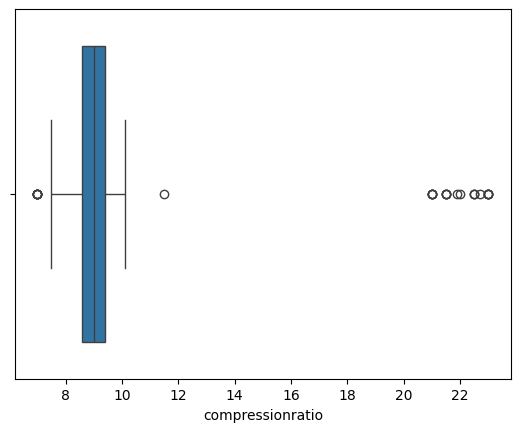

In [170]:
sns.boxplot(x='compressionratio',data=df)
df[['compressionratio']].describe().T.style.background_gradient(
    subset=['min', '50%', 'max'], cmap='Blues').set_properties(
        **{'font-size': '10pt', 'border': '0.5px solid black'})
#like the 'stroke' case
# the range is relatively small (7 to 23),
# and many detected "outliers" seem to be part of the normal distribution,
# so capping may remove useful information. Keeping as is.

<Axes: ylabel='carlength'>

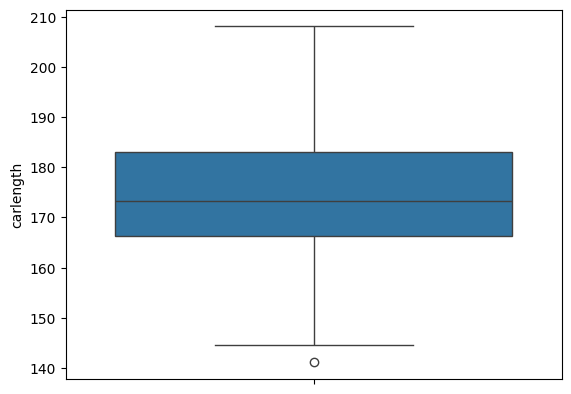

In [171]:
display(sns.boxplot(y='carlength',data=df))

#just 1 outlier so i will cap it to the lower bound
df['carlength']=df['carlength'].clip(lower=getLower(df,'carlength'))

In [172]:
count_outliers(df,numerical_columns).T

,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,highwaympg,horsepower,citympg,peakrpm,price,stroke,compressionratio,cylindernumber
outlier_count,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,15.000000,20.000000,28.000000,46.000000
percentage,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7.317073,9.756098,13.658537,22.439024


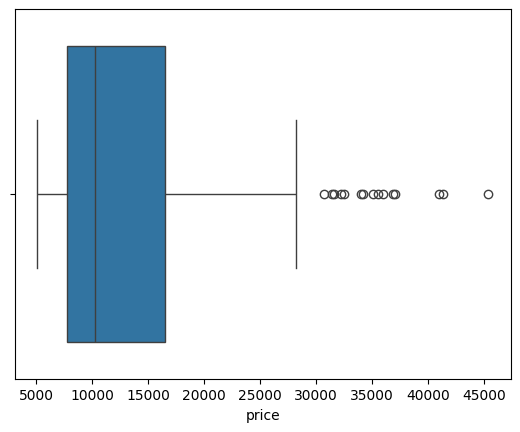

In [173]:
sns.boxplot(data=df,x='price')

# I can't cap outliers, since capping may remove useful information.
# so i will use a diff approch (log transformation)
df['price_log'] = np.log1p(df['price'])
# Log transformation was applied to reduce skewness and lessen the impact of extreme values.

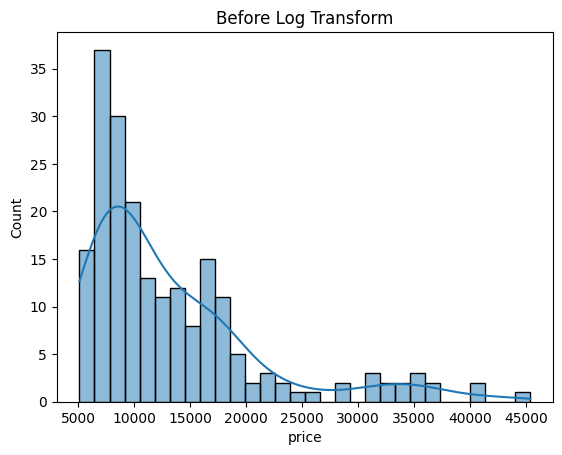

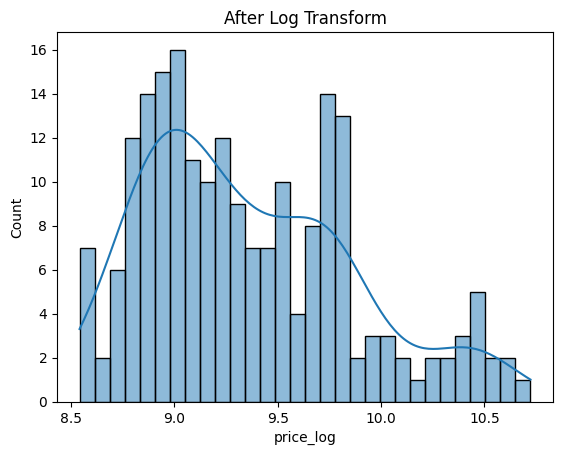

In [174]:
sns.histplot(df['price'], bins=30, kde=True)
plt.title('Before Log Transform')
plt.show()

sns.histplot(df['price_log'], bins=30, kde=True)
plt.title('After Log Transform')
plt.show()

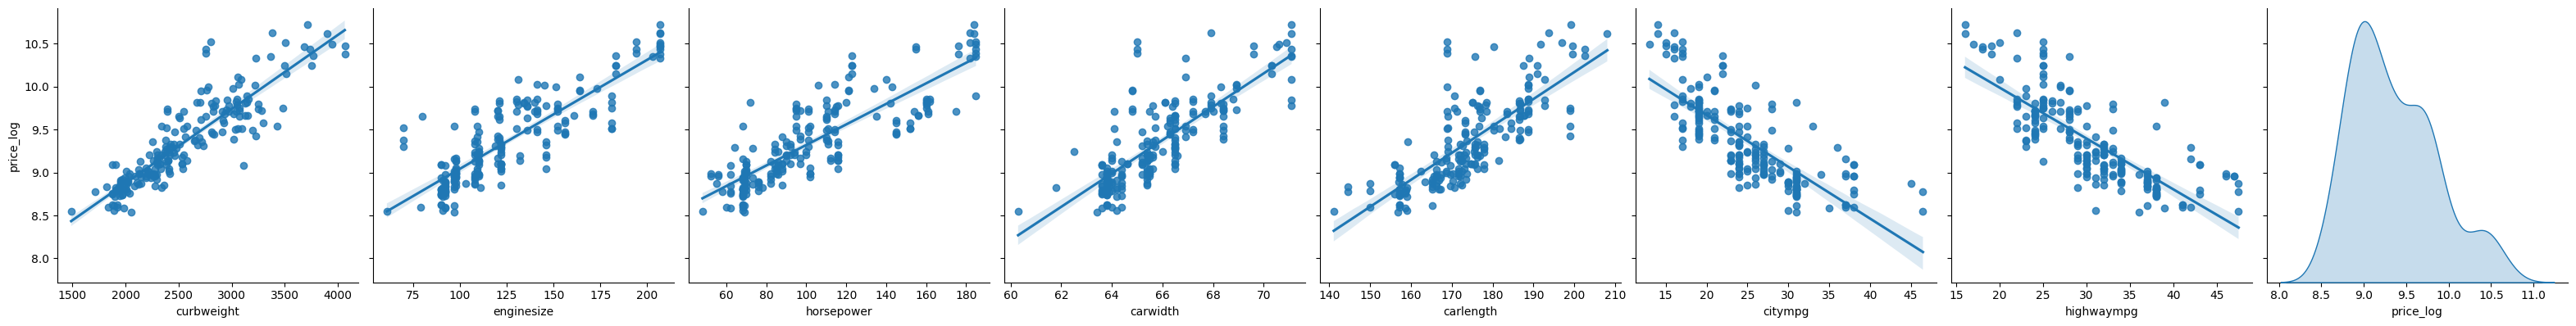

In [175]:
features = [
    'curbweight',
    'enginesize',
    'horsepower',
    'carwidth',
    'carlength',
    'citympg',
    'highwaympg',
    'price_log'
]

sns.pairplot(
    df[features],
    y_vars=['price_log'],
    diag_kind='kde',
     kind='reg',
     height=4
)

plt.show()

# Feature Engineering

In [176]:
information(df)

,Name,Data_Type,Top_10_Unique_Values,Nunique_Values,Nulls,Percent_of_Nulls,Duplicates
0,symboling,int64,"[0, 1, 2, 3, -1, -2]",6,0,0.0,0
1,CarName,object,"[peugeot 504, toyota corolla, toyota corona, s...",147,0,0.0,0
2,fueltype,category,"[gas, diesel]",2,0,0.0,0
3,aspiration,category,"[std, turbo]",2,0,0.0,0
4,doornumber,category,"[4, 2]",2,0,0.0,0
5,carbody,object,"[sedan, hatchback, wagon, hardtop, convertible]",5,0,0.0,0
6,drivewheel,category,"[fwd, rwd, 4wd]",3,0,0.0,0
7,enginelocation,category,"[front, rear]",2,0,0.0,0
8,wheelbase,float64,"[94.5, 93.7, 95.7, 96.5, 98.4, 97.3, 96.3, 99....",52,0,0.0,0
9,carlength,float64,"[157.3, 188.8, 186.7, 166.3, 171.7, 177.8, 165...",75,0,0.0,0


In [177]:
df['Brand']=df['CarName'].str.split().str[0]

df['carSize'] = df['carheight'] * df['carwidth'] * df['carlength'] # This feature approximates total vehicle size/volume.


# Split Data

In [178]:
# Drop irrevelant columns
df.drop('CarName',axis=1,inplace=True)

In [179]:
# Splitting
x = df.drop(columns=['price_log','price'], axis=1)
y = df['price_log']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42)

## Encoding & Scaling (if needed)

In [180]:
categorical_columns=pd.DataFrame(df.select_dtypes(include=['bool','category','object']))
information(categorical_columns)

,Name,Data_Type,Top_10_Unique_Values,Nunique_Values,Nulls,Percent_of_Nulls,Duplicates
0,fueltype,category,"[gas, diesel]",2,0,0.0,76
1,aspiration,category,"[std, turbo]",2,0,0.0,76
2,doornumber,category,"[4, 2]",2,0,0.0,76
3,carbody,object,"[sedan, hatchback, wagon, hardtop, convertible]",5,0,0.0,76
4,drivewheel,category,"[fwd, rwd, 4wd]",3,0,0.0,76
5,enginelocation,category,"[front, rear]",2,0,0.0,76
6,enginetype,object,"[ohc, ohcf, ohcv, dohc, l, rotor, dohcv]",7,0,0.0,76
7,fuelsystem,object,"[mpfi, 2bbl, idi, 1bbl, spdi, 4bbl, mfi, spfi]",8,0,0.0,76
8,Brand,object,"[toyota, nissan, mazda, honda, mitsubishi, sub...",28,0,0.0,76


In [181]:
#01 encoding on categorical columns
onehotcolumns=['drivewheel','carbody','fuelsystem','enginetype','enginelocation','aspiration','fueltype']

OHE=OneHotEncoder(drop='first', handle_unknown='ignore',sparse_output=False)
x_train_encoded=OHE.fit_transform(x_train[onehotcolumns])
x_test_encoded= OHE.transform(x_test[onehotcolumns])

encoded_cols = OHE.get_feature_names_out(onehotcolumns)
x_train_encoded = pd.DataFrame(
    x_train_encoded,
    columns=encoded_cols,
    index=x_train.index
)

x_test_encoded = pd.DataFrame(
    x_test_encoded,
    columns=encoded_cols,
    index=x_test.index
)

x_train = x_train.drop(columns=onehotcolumns)
x_test  = x_test.drop(columns=onehotcolumns)

x_train = pd.concat([x_train, x_train_encoded], axis=1)
x_test  = pd.concat([x_test, x_test_encoded], axis=1)



/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [182]:
#02 encoding Brand by frequency
brand_freq = x_train['Brand'].value_counts(normalize=True)
x_train['Brand_freq'] = x_train['Brand'].map(brand_freq)
x_test['Brand_freq']  = x_test['Brand'].map(brand_freq).fillna(brand_freq.min())
x_train.drop(columns='Brand', inplace=True)
x_test.drop(columns='Brand', inplace=True)


In [183]:
x_train.T

,177,75,174,31,12,35,125,42,156,136,...,121,204,20,188,71,106,14,92,179,102
symboling,-1.00000,1.000000,-1.00000,2.000000,0.000000,0.000000,3.000000,1.000000,0.00000,3.000000,...,1.000000,-1.000000,0.000000,2.000000,-1.000000,1.000000,1.000000,1.000000,3.00000,0.000000
doornumber,4.00000,2.000000,4.00000,2.000000,2.000000,4.000000,2.000000,2.000000,4.00000,2.000000,...,4.000000,4.000000,4.000000,4.000000,4.000000,2.000000,4.000000,4.000000,2.00000,4.000000
wheelbase,102.40000,102.700000,102.40000,86.600000,101.200000,96.500000,94.500000,96.500000,95.70000,99.100000,...,93.700000,109.100000,94.500000,97.300000,114.250000,99.200000,103.500000,94.500000,102.90000,100.400000
carlength,175.60000,178.400000,175.60000,144.600000,176.800000,163.400000,168.900000,169.100000,166.30000,186.600000,...,167.300000,188.800000,158.800000,171.700000,202.600000,178.500000,189.000000,165.300000,183.50000,184.600000
carwidth,66.50000,68.000000,66.50000,63.900000,64.800000,64.000000,68.300000,66.000000,64.40000,66.500000,...,63.800000,68.900000,63.600000,65.500000,71.100000,67.900000,66.900000,63.800000,67.70000,66.500000
carheight,53.90000,54.800000,54.90000,50.800000,54.300000,54.500000,50.200000,51.000000,53.00000,56.100000,...,50.800000,55.500000,52.000000,55.700000,56.500000,49.700000,55.700000,54.500000,52.00000,56.100000
curbweight,2458.00000,2910.000000,2480.00000,1819.000000,2710.000000,2010.000000,2778.000000,2293.000000,2081.00000,2808.000000,...,1989.000000,3062.000000,1909.000000,2300.000000,3740.000000,3139.000000,3055.000000,1938.000000,3016.00000,3296.000000
cylindernumber,4.00000,4.000000,4.00000,4.000000,6.000000,4.000000,4.000000,4.000000,4.00000,4.000000,...,4.000000,4.000000,4.000000,4.000000,8.000000,6.000000,6.000000,4.000000,6.00000,6.000000
enginesize,122.00000,140.000000,110.00000,92.000000,164.000000,92.000000,151.000000,110.000000,98.00000,121.000000,...,90.000000,141.000000,90.000000,109.000000,207.000000,181.000000,164.000000,97.000000,171.00000,181.000000
boreratio,3.31000,3.780000,3.27000,2.910000,3.310000,2.910000,3.940000,3.150000,3.19000,3.540000,...,2.970000,3.780000,3.030000,3.190000,3.460000,3.430000,3.310000,3.150000,3.27000,3.430000


In [184]:
# 03 scaling
scalingcolumns=['carSize','curbweight','peakrpm','wheelbase','highwaympg','enginesize','carlength','carwidth','carheight','compressionratio','horsepower','citympg']
scaler=StandardScaler()
x_train[scalingcolumns] = scaler.fit_transform(x_train[scalingcolumns])
x_test[scalingcolumns] = scaler.transform(x_test[scalingcolumns])

# Correlation

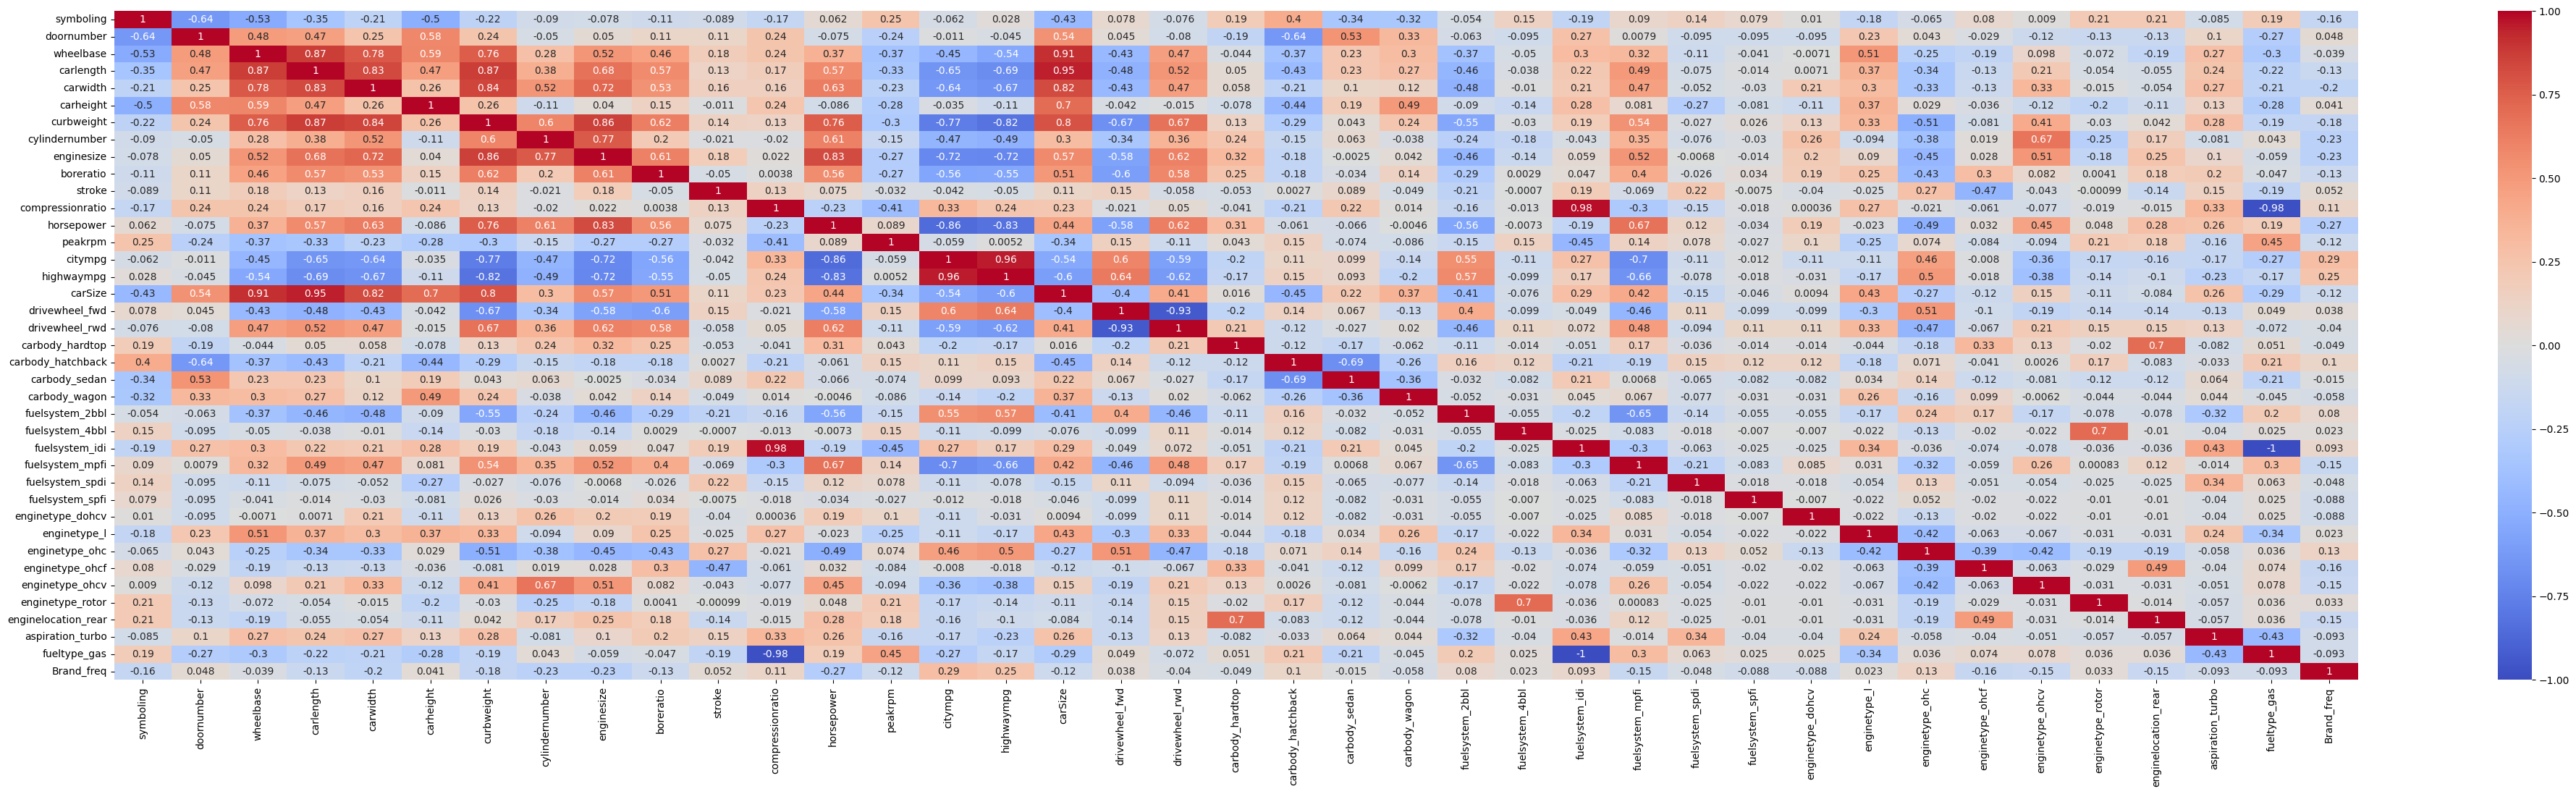

In [185]:
# full correlation matrix
corr =x_train.corr()
plt.figure(figsize=(50,12))
sns.heatmap(corr, annot=True,cmap='coolwarm')
plt.show()

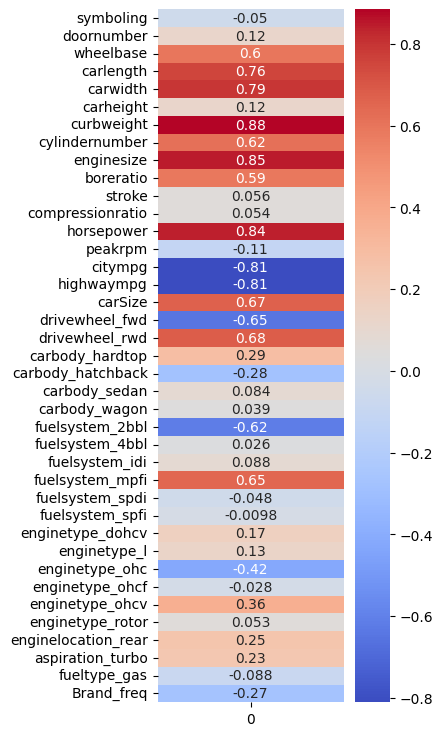

In [186]:
# correlation with target only
corr =x_train.corrwith(y_train)
plt.figure(figsize=(3,9))
sns.heatmap(corr.to_frame(), annot=True,cmap='coolwarm')
plt.show()

Concluded Insights:

1.   Most high positively related features with target "price_log":
     * curbweight
     * enginesize
     * horsepower
     * carwidth
     * carlength
      
2. Most high negatively related features with target:
    * citympg
    * highwaympg
    * drivewheel_fwd
    * fuelsystem_2bbl



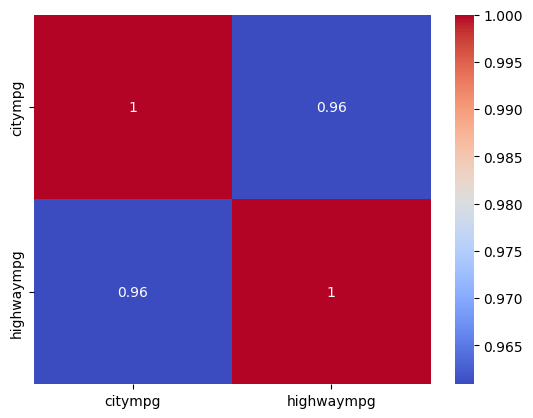

In [187]:
corr =x_train[['citympg','highwaympg']].corr()
sns.heatmap(corr, annot=True,cmap='coolwarm')
plt.show()

### Multicollinearity Check

# A very strong correlation (0.96) was observed between `citympg` and `highwaympg`, indicating potential multicollinearity.

# Since both features carry nearly identical information, one feature was removed to reduce redundancy and improve model simplicity.

Highly correlated features were identified.

Features with correlation coefficients greater than 0.9 were considered redundant and removed to reduce multicollinearity and simplify the model.


In [188]:
# check if there other features correlated with eachother
corr_matrix = x_train.corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr = [
    column for column in upper.columns
    if any(upper[column] > 0.9)
]

display(high_corr)
#drop them to reduce redundancy
x_train.drop(columns=high_corr,inplace=True)
x_test.drop(columns=high_corr,inplace=True)


['highwaympg', 'carSize', 'drivewheel_rwd', 'fuelsystem_idi', 'fueltype_gas']

## Model Training

In [189]:
model = LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

In [190]:
y_pred = model.predict(x_test)
y_train_pred = model.predict(x_train)

## Evaluate Model in Training, Testing

#### 01 Accuracy Score

In [191]:
train_accuracy = model.score(x_train,y_train)
test_accuracy = model.score(x_test,y_test)

print('train:',train_accuracy)
print('test:',test_accuracy)

train: 0.9426169128899693
test: 0.8857259401255454


#### Model Evaluation Metrics

In [192]:
model_evaluation_metrics=pd.DataFrame({
    'R2':[
        r2_score(y_train, y_train_pred),
        r2_score(y_test, y_pred)],
    'MSE':[
        mean_squared_error(y_train, y_train_pred),
        mean_squared_error(y_test, y_pred)],
    'MAE':[
        mean_absolute_error(y_train, y_train_pred),
        mean_absolute_error(y_test, y_pred)]
    },index=['Train','Test'])

model_evaluation_metrics

,R2,MSE,MAE
Train,0.942617,0.014326,0.093966
Test,0.885726,0.029452,0.130252


####  Actual vs Predicted

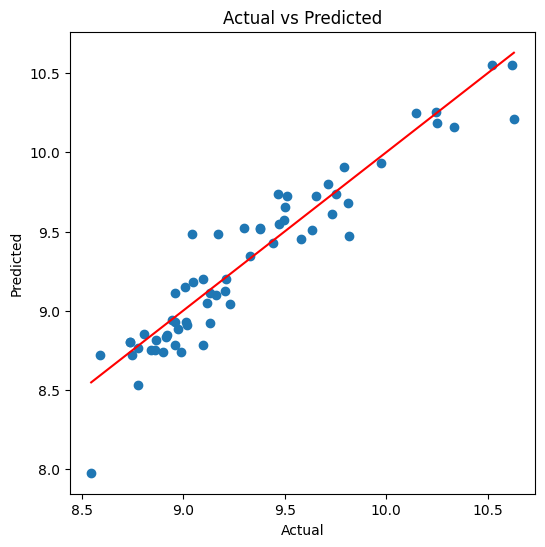

In [193]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red'
)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

## Insights

### Key Insights

- **Engine size and curb weight showed the strongest positive correlation with car price**, indicating that larger and heavier cars tend to be more expensive.

- **Horsepower also had a significant positive relationship with price**, suggesting that performance is an important factor in pricing.

- **Fuel efficiency (city/highway MPG) was negatively correlated with price**, meaning higher-priced cars often prioritize power over fuel economy.

- **Extracting the car brand from `CarName` improved the dataset's predictive power**, showing that brand reputation plays an important role in determining vehicle price.
- **Highly correlated features were removed to reduce multicollinearity**, helping the model generalize better and making coefficient interpretation more reliable.
- **Outliers were capped instead of removed due to the small dataset size**, preserving valuable information while reducing their negative impact on model training.
- **The final model achieved an R² score of approximately 0.89 on the test set**, meaning it can explain around 89% of the variation in car prices.
- **The small gap between training and testing performance indicates minimal overfitting**, suggesting that the model generalizes well to unseen data.
- **Proper preprocessing, feature engineering, and careful handling of outliers significantly improved model stability and predictive performance.**

### Final Conclusion

The analysis showed that car price is mainly influenced by factors related to **vehicle size, performance, and brand identity**.  
Among all features, **engine size, curb weight, and horsepower** were the strongest price indicators.

After preprocessing, handling outliers, and engineering new features, the final regression model achieved **strong predictive performance (R² ≈ 0.89)** with **minimal overfitting**, indicating good generalization on unseen data.